In [24]:
import numpy as np
import pandas as pd
import difflib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [25]:
movies_data=pd.read_csv('movies.csv')

In [26]:
movies_data.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [27]:
movies_data.shape

(4803, 24)

In [28]:
movies_data.columns

Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='object')

In [29]:
movies_data[['title', 'genres', 'keywords', 'overview', 'cast', 'director']].isnull().sum()

title         0
genres       28
keywords    412
overview      3
cast         43
director     30
dtype: int64

In [30]:
selected_features = ['genres', 'keywords', 'overview', 'cast', 'director']

movie_features = movies_data[selected_features].copy()

movie_features.head()

,genres,keywords,overview,cast,director
0,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,"In the 22nd century, a paraplegic Marine is di...",Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,"Captain Barbossa, long believed to be dead, ha...",Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Action Adventure Crime,spy based on novel secret agent sequel mi6,A cryptic message from Bond’s past sends him o...,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,Following the death of District Attorney Harve...,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,"John Carter is a war-weary, former military ca...",Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [31]:
movie_features = movie_features.fillna('') #to combine columns into text

In [32]:
#combining movie features
combined_features = (
    movie_features['genres'] + ' ' +
    movie_features['keywords'] + ' ' +
    movie_features['overview'] + ' ' +
    movie_features['cast'] + ' ' +
    movie_features['director']
)

combined_features.head()

0    Action Adventure Fantasy Science Fiction cultu...
1    Adventure Fantasy Action ocean drug abuse exot...
2    Action Adventure Crime spy based on novel secr...
3    Action Crime Drama Thriller dc comics crime fi...
4    Action Adventure Science Fiction based on nove...
dtype: object

In [33]:
vectorizer = TfidfVectorizer()

feature_vectors = vectorizer.fit_transform(combined_features)

print(feature_vectors.shape)

(4803, 30088)


In [34]:
#calculating cosine similarity
similarity = cosine_similarity(feature_vectors)

print(similarity.shape)

(4803, 4803)


In [35]:
similarity

array([[1.        , 0.03405403, 0.03366926, ..., 0.0198114 , 0.0312866 ,
        0.0070467 ],
       [0.03405403, 1.        , 0.03105138, ..., 0.03489247, 0.02038452,
        0.01381278],
       [0.03366926, 0.03105138, 1.        , ..., 0.02802907, 0.05202542,
        0.01180564],
       ...,
       [0.0198114 , 0.03489247, 0.02802907, ..., 1.        , 0.03743513,
        0.03653328],
       [0.0312866 , 0.02038452, 0.05202542, ..., 0.03743513, 1.        ,
        0.03078044],
       [0.0070467 , 0.01381278, 0.01180564, ..., 0.03653328, 0.03078044,
        1.        ]], shape=(4803, 4803))

In [36]:
movie_name=input("Enter your favourite movie name:")

Enter your favourite movie name: Avatar


In [37]:
list_of_all_titles=movies_data['title'].tolist()
print(list_of_all_titles[:10])

['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre', 'The Dark Knight Rises', 'John Carter', 'Spider-Man 3', 'Tangled', 'Avengers: Age of Ultron', 'Harry Potter and the Half-Blood Prince', 'Batman v Superman: Dawn of Justice']


In [38]:
find_close_match = difflib.get_close_matches(
    movie_name,
    list_of_all_titles
)

print(find_close_match)

['Avatar']


In [39]:
close_match=find_close_match[0]
print(close_match)

Avatar


In [40]:
index_of_the_movie=movies_data[movies_data.title==close_match]['index'].values[0]
print(index_of_the_movie)

0


In [41]:
#similarity score
similarity_score = list(enumerate(similarity[index_of_the_movie]))

print(similarity_score[:10])

[(0, np.float64(1.0000000000000004)), (1, np.float64(0.03405402814249525)), (2, np.float64(0.03366926257068403)), (3, np.float64(0.032304112825120246)), (4, np.float64(0.08152264985022634)), (5, np.float64(0.056295257111312946)), (6, np.float64(0.016826096018427952)), (7, np.float64(0.06899600105825825)), (8, np.float64(0.02103107401156589)), (9, np.float64(0.02923481929758609))]


In [42]:
sorted_similar_movies=sorted(similarity_score, 
                             key=lambda x:x[1], 
                             reverse=True)
print(sorted_similar_movies)

[(0, np.float64(1.0000000000000004)), (1914, np.float64(0.1685354365707052)), (1352, np.float64(0.16136501439998974)), (56, np.float64(0.1590053991302051)), (1531, np.float64(0.15531663564277243)), (94, np.float64(0.1548710196379995)), (2403, np.float64(0.15059794202021132)), (2198, np.float64(0.14364785275583292)), (239, np.float64(0.1422364402192149)), (3158, np.float64(0.14154914455451986)), (461, np.float64(0.13810279480467047)), (1275, np.float64(0.13356010264614593)), (305, np.float64(0.1332619017791768)), (3730, np.float64(0.1328991700842588)), (3604, np.float64(0.13242888505443862)), (1354, np.float64(0.13009071444708348)), (300, np.float64(0.12892127391277805)), (661, np.float64(0.1268450031136837)), (4401, np.float64(0.12673101462572023)), (942, np.float64(0.1263716863710212)), (150, np.float64(0.12143360938843185)), (47, np.float64(0.11928346749706534)), (541, np.float64(0.1191409328994913)), (432, np.float64(0.11865686811981165)), (2229, np.float64(0.11808580605372127)), (4

In [43]:
print("Movies suggested for you:\n")

i = 1

for movie in sorted_similar_movies:
    index = movie[0]

    title_from_index = movies_data[movies_data['index'] == index]['title'].values[0]

    if i <= 30:
        print(i, '.', title_from_index)
        i += 1
    else:
        break

Movies suggested for you:

1 . Avatar
2 . Lifeforce
3 . Gattaca
4 . Star Trek Beyond
5 . Moonraker
6 . Guardians of the Galaxy
7 . Aliens
8 . Lockout
9 . Gravity
10 . Alien
11 . Lost in Space
12 . Sunshine
13 . Treasure Planet
14 . Cargo
15 . Apollo 18
16 . Space Chimps
17 . Starship Troopers
18 . Zathura: A Space Adventure
19 . The Helix... Loaded
20 . The Book of Life
21 . Men in Black II
22 . Star Trek Into Darkness
23 . Soldier
24 . Deep Impact
25 . Machete Kills
26 . Trekkies
27 . Sphere
28 . Silent Running
29 . Galaxy Quest
30 . Transformers: Dark of the Moon


In [44]:
def recommend_movies(movie_name, number_of_recommendations=10):

    list_of_all_titles = movies_data['title'].tolist()

    find_close_match = difflib.get_close_matches(
        movie_name,
        list_of_all_titles
    )

    if not find_close_match:
        print("Movie not found. Please try another movie name.")
        return

    close_match = find_close_match[0]

    print("Selected Movie:", close_match)
    print("\nMovies suggested for you:\n")

    index_of_the_movie = movies_data[
        movies_data.title == close_match
    ]['index'].values[0]

    similarity_score = list(
        enumerate(similarity[index_of_the_movie])
    )

    sorted_similar_movies = sorted(
        similarity_score,
        key=lambda x: x[1],
        reverse=True
    )

    i = 0

    for movie in sorted_similar_movies:

        index = movie[0]

        title_from_index = movies_data[
            movies_data['index'] == index
        ]['title'].values[0]

        if title_from_index != close_match:

            print(i + 1, ".", title_from_index)

            i += 1

            if i >= number_of_recommendations:
                break

In [45]:
print(type(recommend_movies))

<class 'function'>


In [46]:
recommend_movies("Avatr")


Selected Movie: Avatar

Movies suggested for you:

1 . Lifeforce
2 . Gattaca
3 . Star Trek Beyond
4 . Moonraker
5 . Guardians of the Galaxy
6 . Aliens
7 . Lockout
8 . Gravity
9 . Alien
10 . Lost in Space


In [47]:
recommend_movies("This Movie Does Not Exist")

Movie not found. Please try another movie name.


In [48]:
movies_data[
    movies_data['title'] == 'Avatar'
][['title', 'genres', 'keywords', 'overview', 'director']]

,title,genres,keywords,overview,director
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,"In the 22nd century, a paraplegic Marine is di...",James Cameron


In [49]:
avatar_index = movies_data[
    movies_data['title'] == 'Avatar'
]['index'].values[0]

titanic_index = movies_data[
    movies_data['title'] == 'Titanic'
]['index'].values[0]

print(
    "Similarity between Avatar and Titanic:",
    similarity[avatar_index][titanic_index]
)

Similarity between Avatar and Titanic: 0.03280264955830792


# Movie Recommendation Engine

### Machine Learning Internship Project

**Technique Used:** Content-Based Filtering  
**Feature Extraction:** TF-IDF Vectorization  
**Similarity Measure:** Cosine Similarity

## Project Description

This project implements a content-based movie recommendation system.

The system uses information such as genres, keywords, movie overview, cast and director to determine the similarity between movies.

TF-IDF Vectorization is used to convert the combined textual movie features into numerical feature vectors.

Cosine Similarity is then used to calculate the similarity between movies.

When a user enters a movie name, the system identifies the closest matching movie and recommends other movies with the highest similarity scores.

In [50]:
print(type(recommend_movies))

<class 'function'>


In [51]:
recommend_movies("Titanic")

Selected Movie: Titanic

Movies suggested for you:

1 . Ghost Ship
2 . Raise the Titanic
3 . The Chambermaid on the Titanic
4 . The Black Hole
5 . In the Heart of the Sea
6 . Pieces of April
7 . I Can Do Bad All By Myself
8 . Event Horizon
9 . Birth
10 . Go for It!


In [52]:
recommend_movies("The Avengers")

Selected Movie: The Avengers

Movies suggested for you:

1 . Avengers: Age of Ultron
2 . Captain America: The Winter Soldier
3 . Iron Man 2
4 . Captain America: Civil War
5 . The Incredible Hulk
6 . X-Men
7 . Thor: The Dark World
8 . X-Men: Apocalypse
9 . Captain America: The First Avenger
10 . X-Men: Days of Future Past


## Data Visualization

Before making the recommendation system, I wanted to look at some basic information in the dataset using graphs.

Matplotlib is used for the visualizations below.

In [53]:
import matplotlib.pyplot as plt

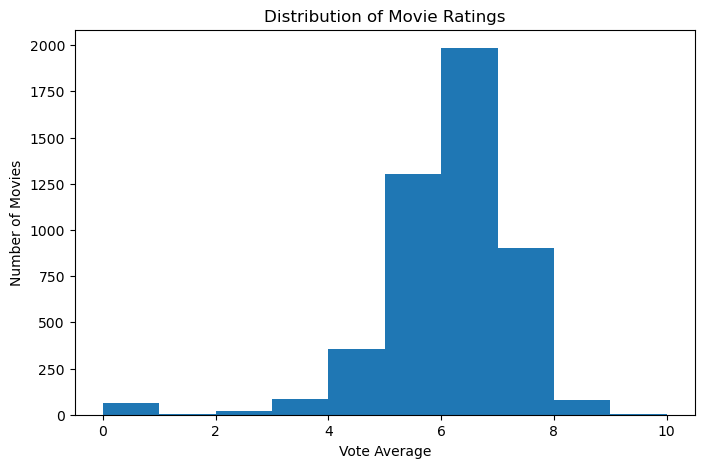

In [54]:
plt.figure(figsize=(8,5))

plt.hist(movies_data['vote_average'], bins=10)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')

plt.show()

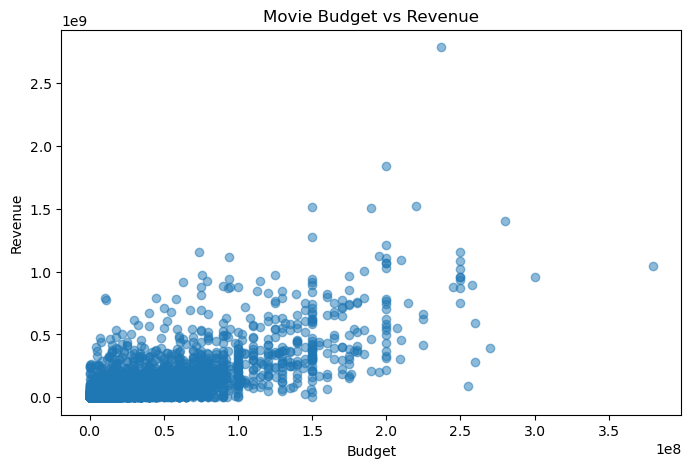

In [55]:
#a scatter plot for movies budget vs revenue
plt.figure(figsize=(8,5))

plt.scatter(
    movies_data['budget'],
    movies_data['revenue'],
    alpha=0.5
)

plt.title('Movie Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')

plt.show()

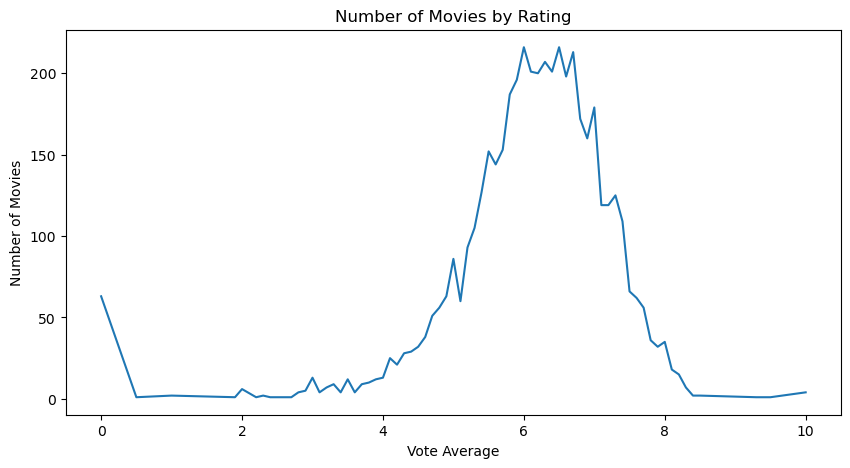

In [56]:
#a line graph to show movie ratings
rating_counts = movies_data['vote_average'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    rating_counts.index,
    rating_counts.values
)

plt.title('Number of Movies by Rating')
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')

plt.show()

In [57]:
print(movies_data['genres'].iloc[0])

Action Adventure Fantasy Science Fiction


In [58]:
genre_counts = movies_data['genres'].str.split().explode().value_counts()

genre_counts.head(10)

genres
Drama        2297
Comedy       1722
Thriller     1259
Action       1153
Romance       890
Adventure     790
Crime         696
Fiction       530
Science       530
Horror        519
Name: count, dtype: int64

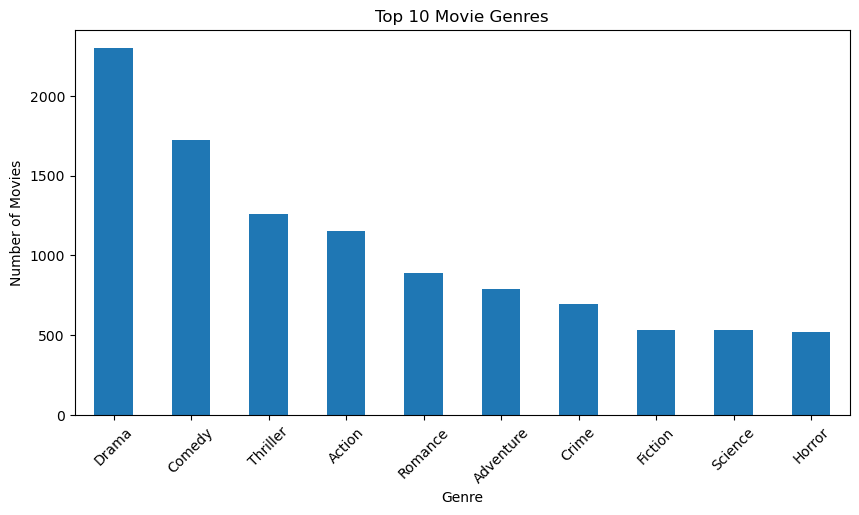

In [59]:
plt.figure(figsize=(10,5))

genre_counts.head(10).plot(kind='bar')

plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45)

plt.show()

In [60]:
#movies by release year
movies_data['release_date'] = pd.to_datetime(
    movies_data['release_date'],
    errors='coerce'
)

movies_data['release_year'] = movies_data['release_date'].dt.year

movies_data[['title', 'release_year']].head()

,title,release_year
0,Avatar,2009.0
1,Pirates of the Caribbean: At World's End,2007.0
2,Spectre,2015.0
3,The Dark Knight Rises,2012.0
4,John Carter,2012.0


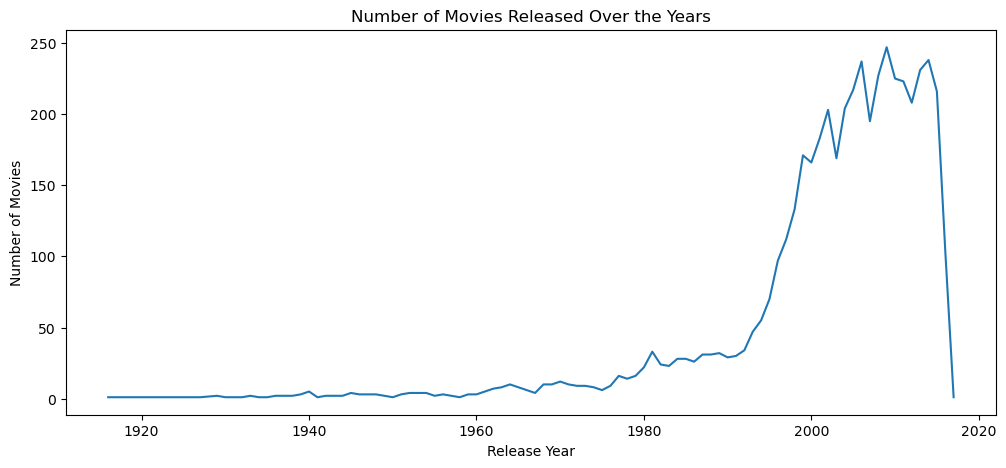

In [61]:
#movies released over the years
year_counts = movies_data['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.title('Number of Movies Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')

plt.show()

## What I Observed from the Data

From the graphs, we can see that the dataset contains movies from different years and different genres.

The ratings are also distributed across different values.

The budget and revenue graph gives an idea about the relationship between the amount spent on a movie and its revenue.

The genre graph shows which movie genres are more common in the dataset.

## Recommendation System

After looking at the dataset and its features, I used the movie information to build the recommendation system.

The important features used were genres, keywords, overview, cast and director.

## TF-IDF and Cosine Similarity

The selected movie features were combined into one column.

TF-IDF Vectorizer was then used to convert the text into numerical feature vectors.

After that, Cosine Similarity was used to find how similar one movie is to the other movies.

In [62]:
#final testing
recommend_movies("Avatar", 10)

Selected Movie: Avatar

Movies suggested for you:

1 . Lifeforce
2 . Gattaca
3 . Star Trek Beyond
4 . Moonraker
5 . Guardians of the Galaxy
6 . Aliens
7 . Lockout
8 . Gravity
9 . Alien
10 . Lost in Space


In [63]:
recommend_movies("Thor", 10)

Selected Movie: Thor

Movies suggested for you:

1 . Thor: The Dark World
2 . The Avengers
3 . Pirates of the Caribbean: At World's End
4 . Man of Steel
5 . Angels & Demons
6 . Avengers: Age of Ultron
7 . Cinderella
8 . Hamlet
9 . Henry V
10 . Little Nicky


## Objective

The aim of this project was to make a simple movie recommendation system.

The system takes a movie name from the user and recommends other movies which are similar to it.

I used movie features from the dataset and calculated their similarity using TF-IDF and Cosine Similarity.

## Limitations

- The recommendations depend on the information available in the dataset.
- The system does not use the user's personal ratings or watching history.
- Sometimes the recommended movies may not match the user's personal taste.
- The recommendations depend on the features selected for the project.

## Conclusion

In this project, I made a simple movie recommendation system using Python.

I first explored the dataset using Pandas and Matplotlib.

Then I combined some movie features and used TF-IDF Vectorization to convert the text into numerical values.

Cosine Similarity was used to find similar movies.

The final system takes a movie name and gives a list of similar movies as recommendations.

## Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Difflib